In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from calculations import fret_calculations, processing_cleanup
import matplotlib as mpl
from IPython.display import display
import scipy.stats as stats
from calculations.significance import set_pvalue
import matplotlib.patches as mpatches

mpl.style.use('default')
mpl.rcParams['axes.linewidth'] = 7  # set the value globally
mpl.rcParams['xtick.major.size'] = 20
mpl.rcParams['xtick.major.width'] = 7
mpl.rcParams['xtick.minor.size'] = 10
mpl.rcParams['xtick.minor.width'] = 7
mpl.rcParams['ytick.major.size'] = 20
mpl.rcParams['ytick.major.width'] = 7
mpl.rcParams['ytick.labelsize'] = 50
mpl.rcParams['xtick.labelsize'] = 50
mpl.rcParams['ytick.minor.size'] = 10
mpl.rcParams['ytick.minor.width'] = 7
mpl.rcParams['font.size'] = 55
mpl.rcParams['font.sans-serif'] = 'Arial'
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['svg.fonttype'] = 'none'

In [4]:
raw_data_path = r'W:\OneDrive\Virus\Paper1\Raw_data_CSVs\Other\\'
df = pd.read_csv(raw_data_path + 'blasticidin_df.csv')
df = df.iloc[:, 2:]

display(df)

,label,area,donor_intensity_mean,donor_intensity_min,donor_intensity_max,donor_intensity_std,acceptor_intensity_mean,acceptor_intensity_min,acceptor_intensity_max,acceptor_intensity_std,...,experiment,experimentcondition,experimentparameter,replicate,passages,exposurecam1,exposurecam2,cyanled,blueled,greenled
0,1,79.0,2371.354492,974.0,4001.0,962.025146,3565.543945,1458.206177,6026.708496,1620.833374,...,Blasticidin,Blasticidin,10,1,21,25,25,12U5,12U5,6U5
1,2,15691.0,1150.121704,237.0,2776.0,674.194519,1841.188232,349.108673,4546.009766,1095.067139,...,Blasticidin,Blasticidin,10,1,21,25,25,12U5,12U5,6U5
2,3,16095.0,1005.859436,223.0,2602.0,564.546082,1613.814697,360.994843,4027.994385,903.070740,...,Blasticidin,Blasticidin,10,1,21,25,25,12U5,12U5,6U5
3,4,3233.0,420.825867,222.0,702.0,77.557243,638.408264,315.082977,1048.034668,149.474106,...,Blasticidin,Blasticidin,10,1,21,25,25,12U5,12U5,6U5
4,5,3746.0,867.843811,265.0,1697.0,400.294983,1215.516235,409.803650,2297.798584,523.943726,...,Blasticidin,Blasticidin,10,1,21,25,25,12U5,12U5,6U5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295671,5,4449.0,8525.454102,941.0,15508.0,3700.027588,11813.906250,1042.524902,21630.470703,5811.587402,...,Blasticidin,Growth,0,1,21,25,25,12U5,12U5,6U5
295672,6,5031.0,5405.408203,337.0,12537.0,3675.853760,8541.416016,1119.006226,19261.884766,5619.246094,...,Blasticidin,Growth,0,1,21,25,25,12U5,12U5,6U5
295673,7,14339.0,1574.139282,334.0,3431.0,594.057678,2960.095215,1006.122070,5509.934570,921.735901,...,Blasticidin,Growth,0,1,21,25,25,12U5,12U5,6U5
295674,8,4533.0,5448.688477,731.0,10115.0,2352.022217,8179.415039,827.708618,15013.166992,3831.283447,...,Blasticidin,Growth,0,1,21,25,25,12U5,12U5,6U5


In [39]:
comb_df = df

tmp_df = processing_cleanup.pixels_to_micron(comb_df)
tmp_df = fret_calculations.acceptor_correction(tmp_df)
tmp_df = fret_calculations.calculate_efret(tmp_df)
tmp_df = processing_cleanup.area_cutoffs(tmp_df)
tmp_df = processing_cleanup.remove_maximums(tmp_df, 'directAcceptor')
tmp_df = processing_cleanup.remove_minimums(tmp_df, 'directAcceptor', value_cutoff=200)
tmp_df = processing_cleanup.directacceptor_mean_cutoffs(tmp_df, lower_cutoff=800)
tmp_df = processing_cleanup.donor_mean_cutoffs(tmp_df)
print(len(tmp_df))

192592


Index(['label', 'area_pixels', 'donor_intensity_mean', 'donor_intensity_min',
       'donor_intensity_max', 'donor_intensity_std', 'acceptor_intensity_mean',
       'acceptor_intensity_min', 'acceptor_intensity_max',
       'acceptor_intensity_std', 'directAcceptor_intensity_mean',
       'directAcceptor_intensity_min', 'directAcceptor_intensity_max',
       'directAcceptor_intensity_std', 'timepoint', 'date', 'techReplicate',
       'well', 'construct', 'experiment', 'experimentcondition',
       'experimentparameter', 'replicate', 'passages', 'exposurecam1',
       'exposurecam2', 'cyanled', 'blueled', 'greenled', 'area_micron',
       'crossexcitation_correction', 'bleedthrough_correction',
       'acceptor_corrected_mean', 'Efret'],
      dtype='object')


<Axes: xlabel='construct', ylabel='Efret'>

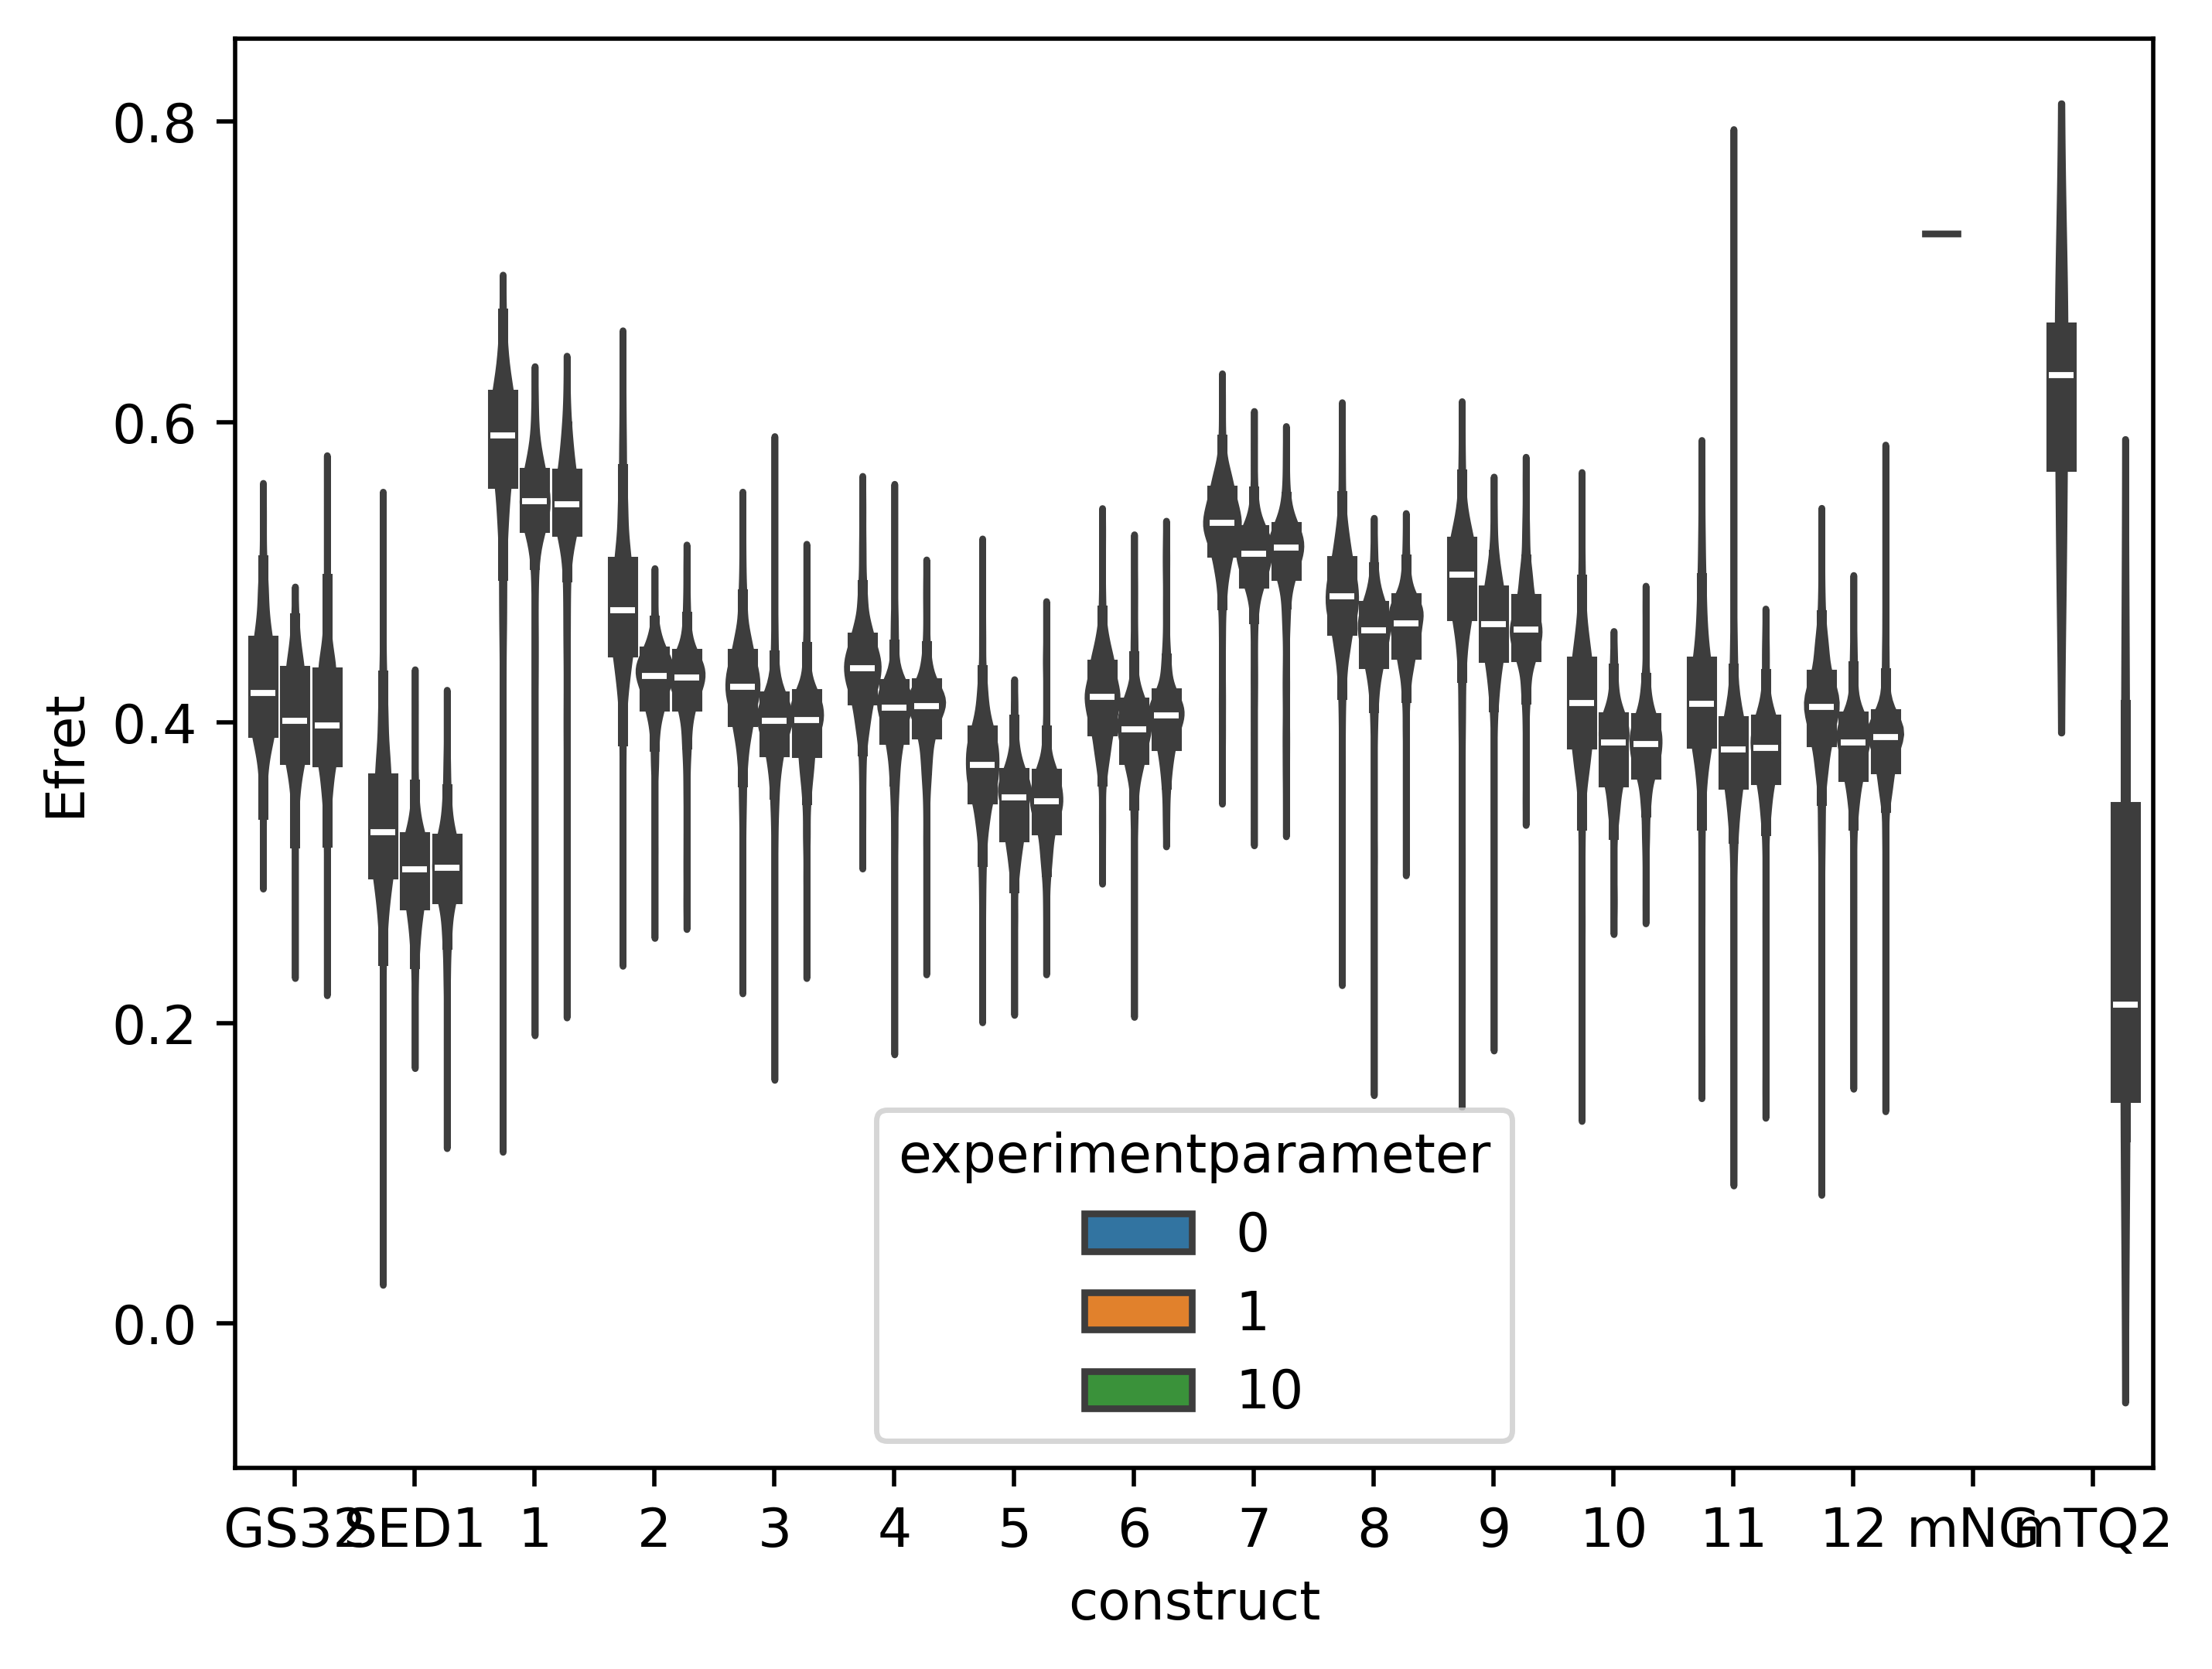

In [40]:
recom_df = tmp_df
recom_df['experimentparameter'] = recom_df['experimentparameter'].astype(str)
#recom_df = recom_df.loc[(recom_df['construct']=='1') | (recom_df['construct']=='4') | (recom_df['construct']=='7') | (recom_df['construct']=='8') | (recom_df['construct']=='9')]

constructs = ['GS32', 'SED1', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
experiment_condition = ['Growth', 'Blasticidin']
experiment_parameter = ['0', '1', '10']

my_sort_dict = {
            'construct' : constructs,
            'experimentcondition': experiment_condition,
            'experimentparameter': experiment_parameter, 
               }

GS32 = recom_df.loc[(recom_df['construct']== 'GS32')]
#recom_df = recom_df.loc[(recom_df['construct']!= 'GS32') & (recom_df['construct']!= 'SED1') &(recom_df['construct']!= 'mTQ2')&(recom_df['construct']!= 'mNG')]
recom_df = processing_cleanup.sort_values(recom_df, my_sort_dict)
recom_df = recom_df.reset_index(drop=True)
if 'Unnamed: 0.1' in recom_df.columns:
    recom_df = recom_df.drop(columns=['Unnamed: 0.1'])
print(recom_df.columns)
sns_df = recom_df.loc[recom_df['timepoint']== 8]
sns.violinplot(data=sns_df, x= 'construct', y='Efret', hue='experimentparameter')


In [41]:
print(len(recom_df))
groupby_values = ['construct', 'experiment', 'experimentcondition', 'experimentparameter',  'timepoint']
filtered_df = processing_cleanup.remove_outliers(recom_df, groupby_values, 'Efret')
print(len(filtered_df))

192592
185880


In [42]:
groupby_values_per_repeat = ['construct', 'date', 'experiment', 'experimentcondition', 'timepoint', 'well', 'experimentparameter']
groupby_values_per_experiment = ['construct', 'experiment', 'experimentcondition',  'timepoint', 'experimentparameter']

total_stats_df = processing_cleanup.get_stats(filtered_df, groupby_values_per_repeat)
experiment_stats = processing_cleanup.get_stats(filtered_df, groupby_values_per_experiment)
#display(total_stats_df)
test = total_stats_df['Efret_list'].apply(np.array) - total_stats_df['Efret_median']

groupby_values_experiment = ['construct', 'experiment', 'experimentcondition', 'experimentparameter', 'timepoint']
total_stats_df = processing_cleanup.drop_counts(total_stats_df, count=25)
holder_df = processing_cleanup.get_population_significance(total_stats_df, groupby_values_experiment, comparison_value = 0, comparison_column='timepoint')

ttest_df = holder_df.dropna()

new_values =  ['construct', 'experiment', 'experimentcondition', 'timepoint', 'experimentparameter']

population_count_df = processing_cleanup.get_stats(total_stats_df, new_values, ['count'], stat_column='Efret_median')
median_std_df = processing_cleanup.get_stats(total_stats_df, new_values, ['std'], stat_column='Efret_median')
list_efret_df = processing_cleanup.get_stats(total_stats_df, new_values, ['list'], stat_column='Efret_median')
population_count_df = population_count_df.drop(columns=new_values)
median_std_df = median_std_df.drop(columns = new_values)
list_efret_df = list_efret_df.drop(columns = new_values)
population_count_df = population_count_df.rename(columns={'Efret_median_count': 'well_count_per_timepoint'})
median_std_df = median_std_df.rename(columns={'Efret_median_std': 'std_median_per_timepoint'})
list_efret_df = list_efret_df.rename(columns={'Efret_median_std': 'list_median_per_timepoint'})

merged_data = pd.concat([experiment_stats, population_count_df, median_std_df, list_efret_df], axis=1)
#merged_data.to_csv(r'E:\Patrick\Test_data.csv')
display(merged_data, ttest_df)
merged_data = merged_data.merge(ttest_df, on=['construct', 'experiment', 'experimentcondition',  'timepoint','experimentparameter'])

merged_delta = merged_data.copy()

merged_delta = processing_cleanup.delta_time(merged_delta, 'Efret_median', group_values = ['construct', 'experiment', 'experimentparameter'], comparison=0)
merged_delta = processing_cleanup.remove_controls(merged_delta)


merged_delta = processing_cleanup.delta_time(merged_delta, 'Efret_median_list', group_values = ['construct', 'experiment', 'experimentparameter'], comparison=0)

total_df = total_stats_df.copy()

total_df = processing_cleanup.delta_time(total_df, 'Efret_median', group_values = ['construct', 'experiment','experimentparameter'], comparison=0)
total_df = processing_cleanup.remove_controls(total_df)


total_df = processing_cleanup.delta_list_median(total_df, merged_delta, 'Efret_list', group_values = ['construct', 'experiment','experimentparameter'], comparison=0)

#merged_delta['delta_median_wells'] = total_df.groupby(['construct', 'experiment', 'experimentparameter', 'timepoint'], observed=False, as_index=False)['delta_Efret_median'].apply(np.array)
#consolidated_values = consolidated_values.loc[(consolidated_values['construct']!= 'mTQ2') & (consolidated_values['construct']!= 'mNG')]
#consolidated_values = consolidated_values.dropna().reset_index(drop=True).rename(columns={'delta_Efret_median': 'delta_median_wells'})

consolidated_values = total_df.groupby(['construct', 'timepoint'], observed=False, as_index=False)['delta_Efret_median'].apply(np.array)
consolidated_values = consolidated_values.loc[(consolidated_values['construct']!= 'mTQ2') & (consolidated_values['construct']!= 'mNG')]

merged_delta = merged_delta.merge(consolidated_values, on=['construct',  'timepoint'], how='left')

#merged_delta = merged_delta.merge(consolidated_values, on=['construct', 'experiment', 'experimentparameter', 'timepoint'], how='left')

#merged_delta['delta_Efret_population'] = total_df.groupby(['construct', 'experiment', 'experimentparameter', 'timepoint'], observed=False, as_index=False)['delta_Efret_list'].apply(np.array)
#consolidated_values = consolidated_values.loc[(consolidated_values['construct']!= 'mTQ2') & (consolidated_values['construct']!= 'mNG')]
#consolidated_values = consolidated_values.dropna().reset_index(drop=True).rename(columns={'delta_Efret_median': 'delta_Efret_population'})
consolidated_values = total_df.groupby(['construct', 'timepoint'], observed=False, as_index=False)['delta_Efret_list'].apply(np.array)
consolidated_values = consolidated_values.loc[(consolidated_values['construct']!= 'mTQ2') & (consolidated_values['construct']!= 'mNG')]
consolidated_values = consolidated_values.dropna().reset_index(drop=True).rename(columns={'delta_Efret_median': 'delta_Efret_population'})

merged_delta = merged_delta.merge(consolidated_values, on=['construct', 'timepoint'], how='left')
#merged_delta = merged_delta.merge(consolidated_values, on=['construct', 'experiment', 'experimentparameter', 'timepoint'], how='left')

tmpr_df = merged_delta.copy()

construct_order = {c: i + 1 for i, c in enumerate(constructs)}


tmpr_df['base_position'] = tmpr_df['construct'].map(construct_order)

# Step 2: For each unique (construct, experimentparameter) pair, compute a subposition offset.
# This mapping is computed once, so it is consistent across all timepoints.
mapping = {}
for construct, order in construct_order.items():
    
    # Get unique experimentparameters for this construct, preserving order of appearance
    unique_params = pd.unique(tmpr_df.loc[tmpr_df['construct'] == construct, 'experimentparameter'])
    n = len(unique_params)
    # Compute offsets evenly in [-0.5, 0.5] (you can adjust the range as needed)
    offsets = (np.arange(n) - (n-1) / 2) / 4
    for exp, offset in zip(unique_params, offsets):
        mapping[(construct, exp)] = offset

# Step 3: Apply the mapping to assign a subposition to every row.
tmpr_df['subposition_offset'] = tmpr_df.apply(lambda row: mapping[(row['construct'], row['experimentparameter'])], axis=1)

tmpr_df['base_position'] = tmpr_df['base_position'].astype(int)
# Step 4: The final plot position for a row is the sum of its base position and subposition offset.
tmpr_df['plot_position'] = tmpr_df['base_position'] + tmpr_df['subposition_offset']
#tmpr_df = tmpr_df.loc[(tmpr_df['timepoint']!=0)]


constructs = ['GS32''1',]
experiment_condition = ['Growth', 'Blasticidin']
experiment_parameter = ['0', '1', '10']

my_sort_dict = {
            'construct' : constructs,
            'experimentcondition': experiment_condition,
            'experimentparameter': experiment_parameter, 
               }


tmpr_df = processing_cleanup.sort_values(tmpr_df, my_sort_dict)

,construct,experiment,experimentcondition,timepoint,experimentparameter,Efret_mean,Efret_median,Efret_min,Efret_max,Efret_std,Efret_count,Efret_var,Efret_list,well_count_per_timepoint,std_median_per_timepoint,Efret_median_list
0,GS32,Blasticidin,Growth,0,0,0.429418,0.427210,0.321829,0.589170,0.036732,941,0.001349,"[0.3824478052710303, 0.36540428732938246, 0.42...",12.0,0.012035,"[0.4266589107225799, 0.4167591108701495, 0.442..."
1,GS32,Blasticidin,Growth,1,0,0.425249,0.422366,0.323505,0.533981,0.035472,682,0.001258,"[0.42768026749002974, 0.36466829246062754, 0.4...",8.0,0.008747,"[0.42810332029047593, 0.4188329575851103, 0.40..."
2,GS32,Blasticidin,Growth,2,0,0.422846,0.419836,0.301665,0.530431,0.033855,712,0.001146,"[0.3343136963984768, 0.3705361893394797, 0.453...",8.0,0.008563,"[0.42646582240438025, 0.41443092180906405, 0.4..."
3,GS32,Blasticidin,Growth,3,0,0.422195,0.418037,0.312096,0.524320,0.033316,711,0.001110,"[0.3700886314666515, 0.3756742077982928, 0.420...",8.0,0.008340,"[0.4253922287541693, 0.41321389402337216, 0.40..."
4,GS32,Blasticidin,Growth,4,0,0.422619,0.417849,0.307076,0.536180,0.034477,717,0.001189,"[0.33967524597927345, 0.3705689971053518, 0.41...",8.0,0.007734,"[0.42410778874996, 0.41754265398812146, 0.4063..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,mTQ2,Blasticidin,Blasticidin,4,10,0.293847,0.239351,0.224235,0.417956,0.107747,3,0.011609,"[0.4179558663783084, 0.23935077449744693, 0.22...",NaN,NaN,NaN
410,mTQ2,Blasticidin,Blasticidin,5,10,0.277513,0.265791,0.159259,0.419213,0.116949,4,0.013677,"[0.4192126940623677, 0.3236428761546432, 0.159...",NaN,NaN,NaN
411,mTQ2,Blasticidin,Blasticidin,6,10,0.237216,0.199623,0.130914,0.427093,0.108482,6,0.011768,"[0.13091363044347334, 0.4270925880597326, 0.16...",NaN,NaN,NaN
412,mTQ2,Blasticidin,Blasticidin,7,10,0.257555,0.216481,0.131508,0.426901,0.128596,5,0.016537,"[0.156713109207166, 0.42690111813195003, 0.131...",NaN,NaN,NaN


,construct,experiment,experimentcondition,experimentparameter,timepoint,ttest,pvalue,star_value
0,GS32,Blasticidin,Growth,0,0,NaN,NaN,ns
1,GS32,Blasticidin,Growth,0,1,1.284463,0.215266,ns
2,GS32,Blasticidin,Growth,0,2,1.703418,0.105693,ns
3,GS32,Blasticidin,Growth,0,3,1.998228,0.061029,ns
4,GS32,Blasticidin,Growth,0,4,2.118638,0.048292,*
...,...,...,...,...,...,...,...,...
373,12,Blasticidin,Blasticidin,10,4,-8.832655,0.0,****
374,12,Blasticidin,Blasticidin,10,5,-8.803546,0.0,****
375,12,Blasticidin,Blasticidin,10,6,-8.508685,0.0,****
376,12,Blasticidin,Blasticidin,10,7,-7.550296,0.000002,****


In [20]:
filtered_df.to_pickle(r'W:\OneDrive\Virus\Paper1\processed_csvs\combined_experiments\blasticidin_tiles.pkl')

In [43]:
tmpr_df

,construct,experiment,experimentcondition,timepoint,experimentparameter,Efret_mean,Efret_median,Efret_min,Efret_max,Efret_std,...,ttest,pvalue,star_value,delta_Efret_median_x,delta_Efret_median_list,delta_Efret_median_y,delta_Efret_list,base_position,subposition_offset,plot_position
0,GS32,Blasticidin,Growth,0,0,0.429418,0.427210,0.321829,0.589170,0.036732,...,NaN,NaN,ns,0.000000,"[-0.0005512442565595022, -0.010451044108989893...","[0.0, -0.009899799852430391, 0.015902130814618...","[[-0.044762349708109106, -0.06180586764975693,...",1,-0.25,0.75
1,GS32,Blasticidin,Growth,1,0,0.425249,0.422366,0.323505,0.533981,0.035472,...,1.284463,0.215266,ns,-0.004844,"[0.0008931653113365412, -0.00837719739402909, ...","[0.0014444095678960434, -0.007825953137469588,...","[[0.00047011251089035255, -0.06254186251851185...",1,-0.25,0.75
2,GS32,Blasticidin,Growth,2,0,0.422846,0.419836,0.301665,0.530431,0.033855,...,1.703418,0.105693,ns,-0.007374,"[-0.0007443325747591434, -0.012779233170075344...","[-0.00019308831819964123, -0.01222798891351584...","[[-0.09289645858066259, -0.05667396563965971, ...",1,-0.25,0.75
3,GS32,Blasticidin,Growth,3,0,0.422195,0.418037,0.312096,0.524320,0.033316,...,1.998228,0.061029,ns,-0.009173,"[-0.0018179262249700678, -0.013996260955767226...","[-0.0012666819684105657, -0.013445016699207724...","[[-0.05712152351248789, -0.051535947180846586,...",1,-0.25,0.75
4,GS32,Blasticidin,Growth,4,0,0.422619,0.417849,0.307076,0.536180,0.034477,...,2.118638,0.048292,*,-0.009361,"[-0.0031023662291793652, -0.00966750099101793,...","[-0.002551121972619863, -0.009116256734458428,...","[[-0.08753490899986593, -0.056641157873787595,...",1,-0.25,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,12,Blasticidin,Blasticidin,4,10,0.386114,0.389639,0.160275,0.506636,0.025993,...,-8.832655,0.0,****,0.011576,"[0.014333414363644104, 0.013521209666883305, 0...","[0.01445461650175578, 0.01744540088235713, 0.0...","[[-0.004520558506307115, -0.0236937989703363, ...",14,0.25,14.25
374,12,Blasticidin,Blasticidin,5,10,0.386815,0.389605,0.169243,0.565527,0.024752,...,-8.803546,0.0,****,0.011541,"[0.014533683524678875, 0.014173299863974476, 0...","[0.016794388408537197, 0.016430863276788554, 0...","[[-0.007903983074756427, 0.01940027919254189, ...",14,0.25,14.25
375,12,Blasticidin,Blasticidin,6,10,0.385827,0.389335,0.179055,0.481553,0.023527,...,-8.508685,0.0,****,0.011271,"[0.012333146011297758, 0.013526882669118001, 0...","[0.013841945128706679, 0.016292183854851205, 0...","[[-0.09566592876320695, -0.005405475598460774,...",14,0.25,14.25
376,12,Blasticidin,Blasticidin,7,10,0.386117,0.389631,0.180123,0.479408,0.023682,...,-7.550296,0.000002,****,0.011567,"[0.012547365640408314, 0.014721837955478656, 0...","[0.01660903878141995, 0.018716776871025465, 0....","[[-0.07017814492945296, -0.001442117308212365,...",14,0.25,14.25


In [55]:
intermediate_df = tmpr_df.loc[tmpr_df['experimentparameter'] != '1']

generator = intermediate_df.groupby('construct', observed=True)
mpl.rcParams['figure.dpi'] = 500
fig_len = 5
fig, ax =plt.subplots(fig_len,  1, figsize=(20,30)) 
for index, container in enumerate(generator):
    construct = container[0]
    
    if index < fig_len:
        container_df = container[1]
        
        
        indexer = 0
        colors = ['k',  'indigo']
        for parameter in container_df.experimentparameter.unique():
            
            current_parameter = container_df.loc[container_df['experimentparameter']== parameter]
            current_parameter['timepoint'] = (current_parameter['timepoint'] * 0.5) 
            
            ax[index].scatter(x=current_parameter['timepoint'], y=current_parameter['delta_Efret_median_x'], alpha=0.6, c=colors[indexer], zorder=3, s=500)
            ax[index].errorbar(current_parameter['timepoint'], current_parameter['delta_Efret_median_x'], yerr = current_parameter['std_median_per_timepoint'], c=colors[indexer],
                                                    capsize=2, capthick=2, alpha=0.6, linewidth=5)
            indexer += 1
        ax[index].set_ylim(-0.03, 0.03)
        ax[index].set_yticks([-0.015, 0, 0.015])
        ax[index].set_xticks([])
        ax[index].axvline(x=0.0, c='k', linestyle='--', linewidth=5)
        ax[index].axhline(y=0.0, c='k', linestyle='--', linewidth=5)
        #ax2 = ax[index].twinx()
        #ax2.set_yticks([])
        #ax2.set_ylabel(ylabel = 'Tile ' + str(construct))

        tick_array = np.array(current_parameter['timepoint'])
        ax[index].set_xticks(tick_array)
fig.suptitle('Blasticidin Experiment Timeline', fontsize=20, x=0.5, y=0.89)
plt.subplots_adjust(hspace=0)
plt.savefig(r'W:\OneDrive\Virus\Paper1\Paper1_figures\blasticidin_timeline_5contructs.svg', format='svg', bbox_inches='tight')

C:\Users\Owner\AppData\Local\Temp\ipykernel_17244\279939325.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  current_parameter['timepoint'] = (current_parameter['timepoint'] * 0.5)


C:\Users\Owner\AppData\Local\Temp\ipykernel_17244\223943333.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_tmp['timepoint'] = new_tmp['timepoint'] * 0.5


KeyError: 'delta_Efret_population'

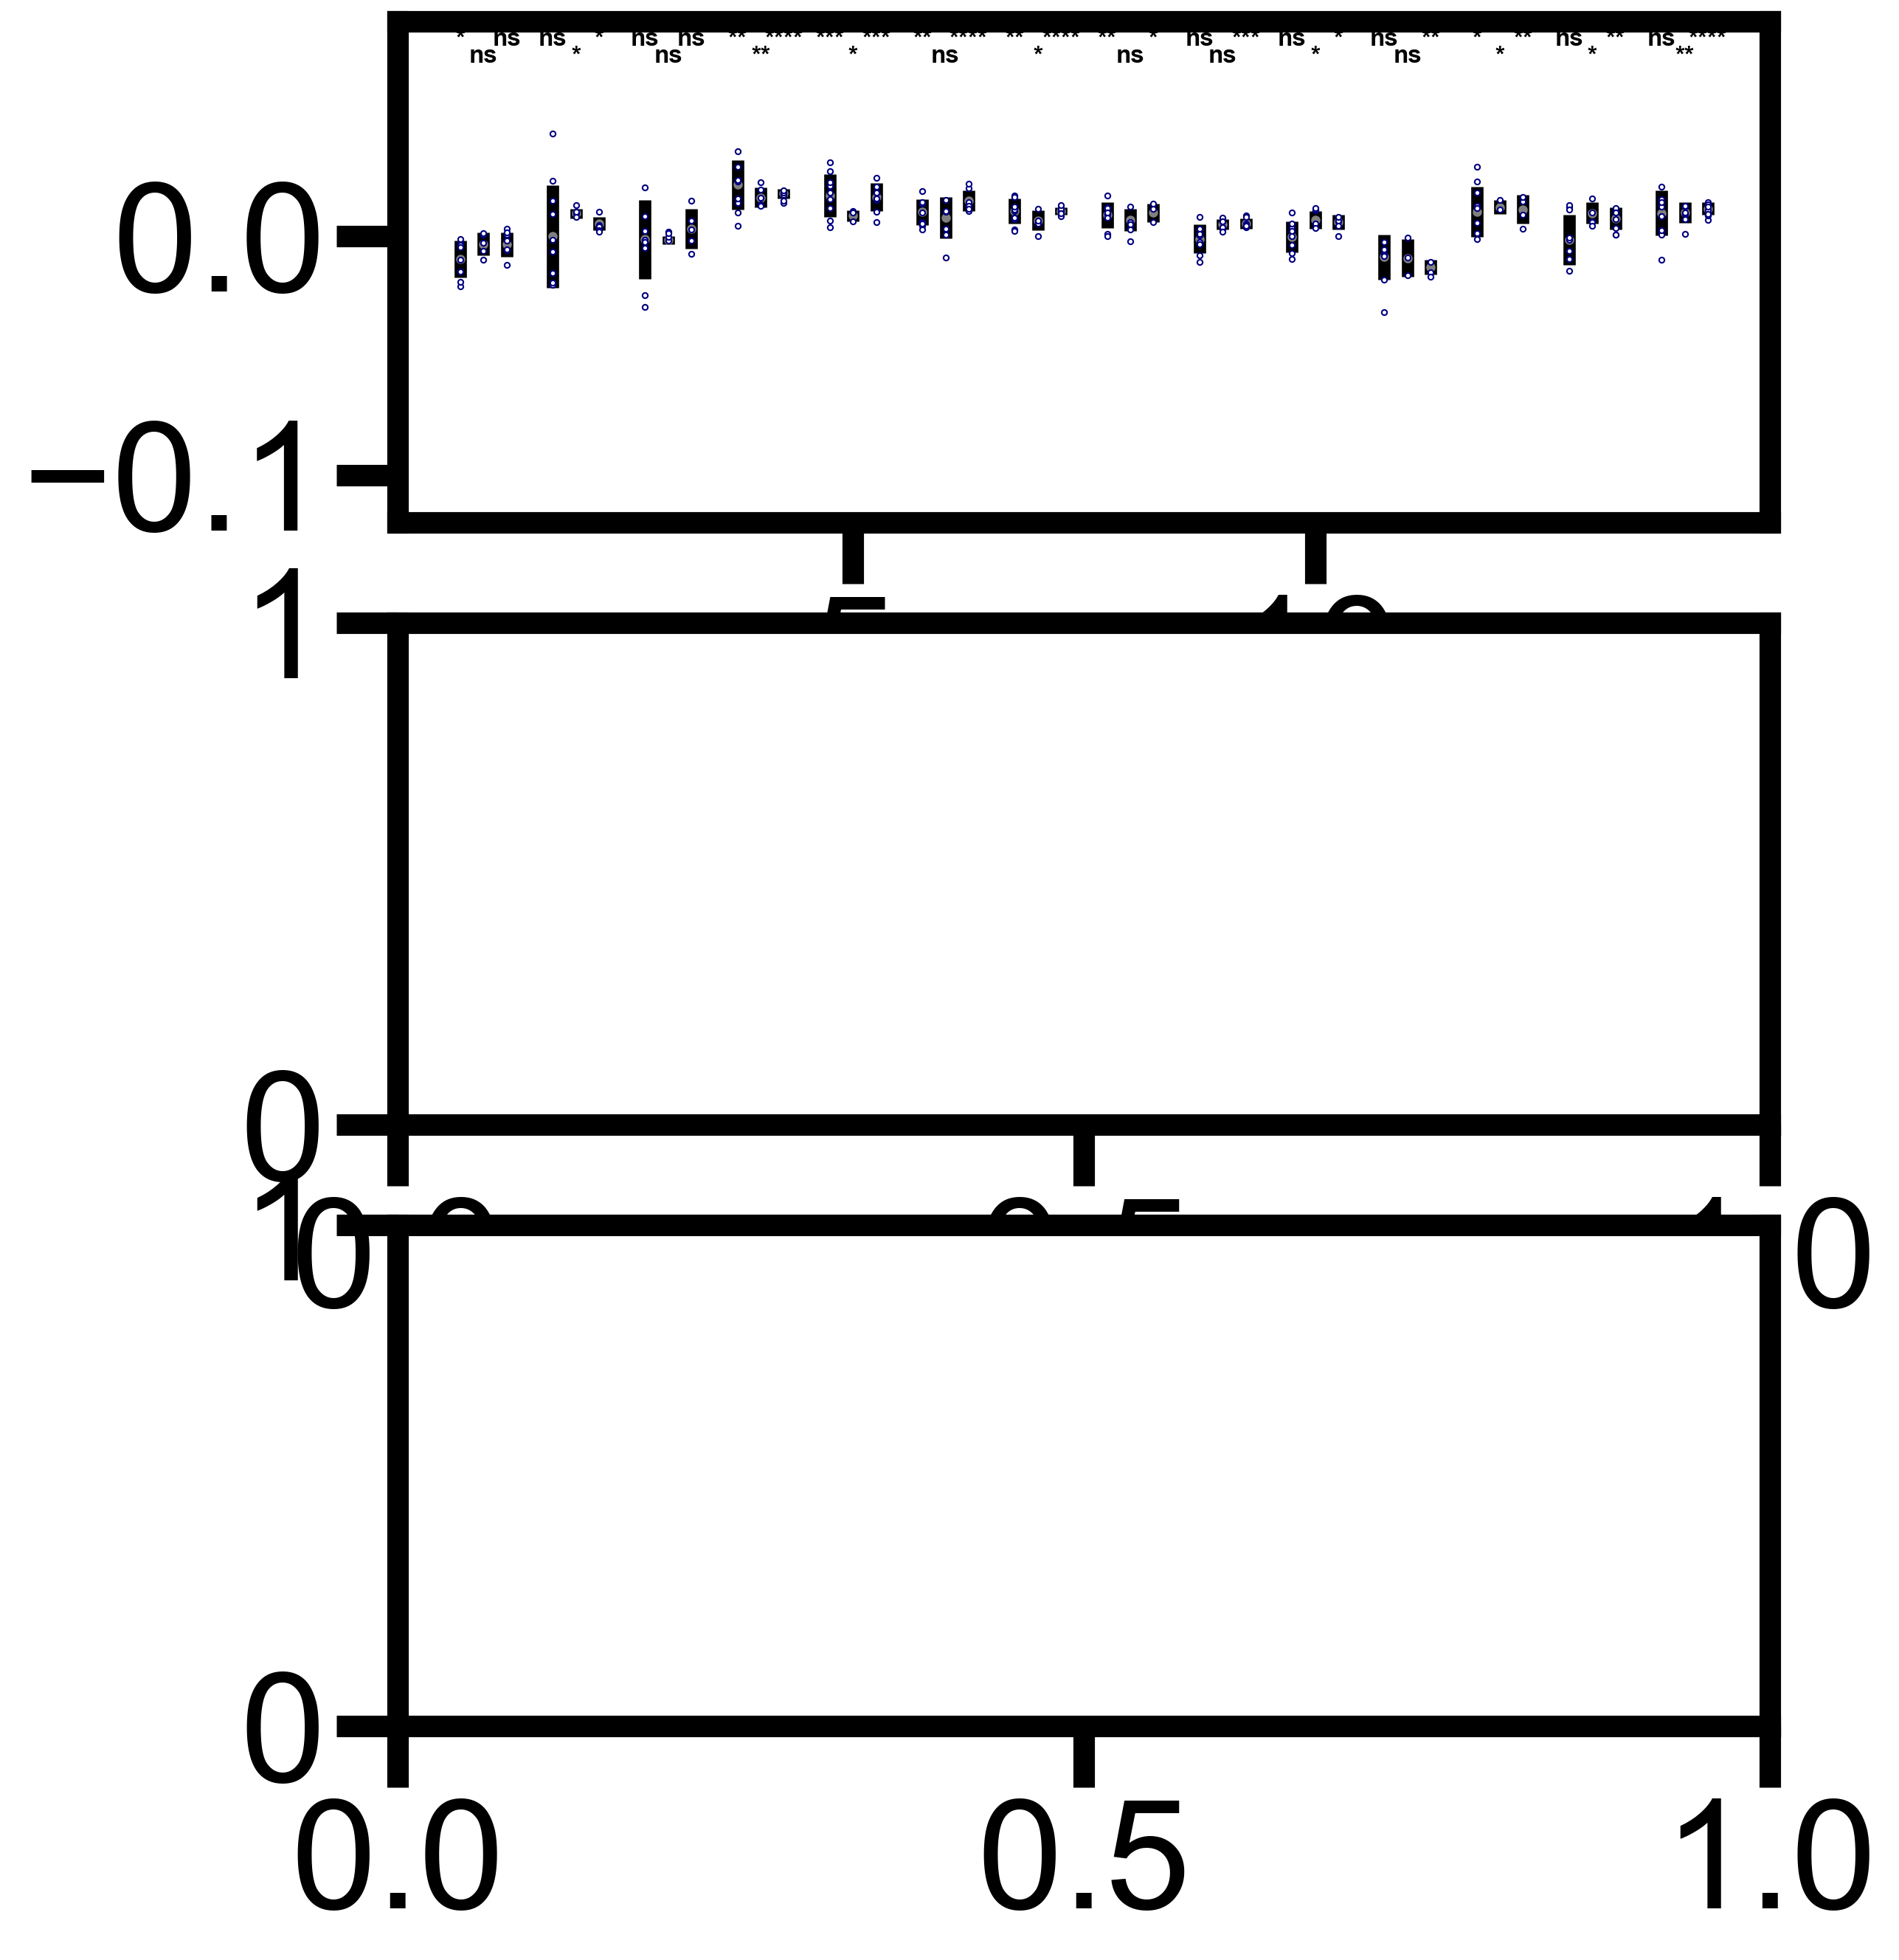

In [52]:
replaced_data = tmpr_df
violin_dataframe_path =r'D:/OneDrive/Virus/Paper1/processed_csvs/heatshock_42-45_violin_csv.csv'
save_csv = False
save_plot = True
if save_csv:
    replaced_data.to_csv(violin_dataframe_path)
reduced_df = replaced_data.loc[(replaced_data['timepoint']==4) | (replaced_data['timepoint']==6) | (replaced_data['timepoint']==8)]

mpl.rcParams['figure.dpi'] = 300
colors = ['k', 'dodgerblue', 'firebrick']

construct = len(reduced_df.construct.unique())
timepoints = len(reduced_df.timepoint.unique())
parameter = len(reduced_df.experimentparameter.unique())
grouped_values = ['timepoint']

uni_construct = reduced_df.construct.unique()
#indexer length
row_len = timepoints

fig, ax = plt.subplots(row_len, 1, figsize=(8, 10))

new_tmp = reduced_df
new_tmp['timepoint'] = new_tmp['timepoint'] * 0.5
median_violin_generator = new_tmp.groupby(grouped_values, observed=True, as_index=True)

for index, container in enumerate(median_violin_generator):
    tmp_df = container[1]
    row = index
    #plots Experiment median and std
    ax[row].scatter(x= tmp_df['plot_position'], y=tmp_df['delta_Efret_median_x'], s=4, c='gray', zorder=3)
    ax[row].errorbar(x= tmp_df['plot_position'], y=tmp_df['delta_Efret_median_x'], yerr= tmp_df['std_median_per_timepoint'], linestyle='none', color='k',elinewidth=4)
    
    #offset star y values
    y=0
    #rest starting put when a new construct is iterated
    con_holder = None
    #plot star values
    for x in tmp_df['plot_position']:
        len_param = tmp_df.experimentparameter.nunique()
        current_construct = tmp_df.loc[tmp_df['plot_position']==x, 'construct'].iloc[0]
        if con_holder is None:
            con_holder = current_construct
            y+=1
             
        if con_holder != current_construct:
            y=0
            con_holder = current_construct
            y+=1
            
        if y == len_param:
            y=0
            y+=1
            
        y_pos = 0.087 - y*0.007
        star_val = tmp_df.loc[tmp_df['plot_position']==x, 'star_value']
        ax[row].text(x, y_pos, s=star_val.iloc[0], fontsize=8, fontweight='bold', ha='center')
        y+=1
    ax[row].set_ylim([-0.12, 0.09])
    tmp_explode = tmp_df.explode('delta_Efret_median_list')
    ax[row].scatter(x=tmp_explode['plot_position'] , y=tmp_explode['delta_Efret_median_list'], s=3, c='white', edgecolor='navy', linewidth=0.5, zorder=3)

    tmp_explode = tmp_df.explode('delta_Efret_population')
    
    iterator = 0 
     
    
    
    for x in tmp_df['plot_position']:
        list_explode = tmp_explode.loc[tmp_explode['plot_position']== x]
        current_parameter = tmp_explode.loc[tmp_explode['plot_position']== x, 'experimentparameter'].iloc[0]
        
        len_dataframe = len(list_explode)
        
        len_para = tmp_explode.experimentparameter.nunique()
        if iterator == len_para:
            iterator = 0
        if 'Growth' == current_parameter:
            iterator = 0 
            
        current_color = colors[iterator]
        
        for sub in range(len_dataframe):
            current_dataframe = list_explode.iloc[sub]
            
            final_explode = current_dataframe['delta_Efret_population']
            violins =ax[row].violinplot(final_explode, [x], widths=0.15, showextrema=False, showmedians=False, showmeans=False)

            
            for pc in violins['bodies']:
                pc.set_facecolor('None')
                pc.set_edgecolor(current_color)
                pc.set_aplha=0.3

        iterator += 1

    ax[row].axhline(y=0, c='k', linestyle ='--')
    ax[row].set_xticks(np.arange(1, construct+1, 1))
    ax[row].set_xticklabels(uni_construct, fontsize='large')


    twinax = ax[row].twinx()
    twinax.set_ylabel('Timepoint: '+ str(int(container[0]) - 1)+ ' (Hours Post Induction)', fontsize=8)
    twinax.set_yticks([])

    ax[row].set_ylabel('Delta Efret', fontsize=20)
ax[-1].set_xlabel('Construct', fontsize=25)

patch = []
labels = [ '0', '1', '10']
for color, label in zip(colors, labels):
    tmp_patch = mpatches.Patch(color=color, label=label)
    patch.append(tmp_patch)
plt.legend(title='Blasticidin', handles=patch, loc='upper right', bbox_to_anchor=(1.35, 2))

fig.suptitle('Blasticidin Experiment', fontsize=15, x=0.5, y=1)
if save_plot:
    plt.savefig(r'D:\OneDrive\Virus\Paper1\Paper1_figures\blasticidin_42-45_violin_5contructs.png', format='png', bbox_inches='tight')
plt.show()
